In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
tf.__version__

'2.20.0'

In [ ]:
!unzip /content/dataset.zip

Archive:  /content/dataset.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/dataset.zip or
        /content/dataset.zip.zip, and cannot find /content/dataset.zip.ZIP, period.


In [ ]:
!unzip /content/dataset.zip

Archive:  /content/dataset.zip
   creating: dataset/
  inflating: dataset/.DS_Store       
   creating: dataset/single_prediction/
  inflating: dataset/single_prediction/cat_or_dog_1.jpg  
  inflating: dataset/single_prediction/cat_or_dog_2.jpg  
   creating: dataset/test_set/
  inflating: dataset/test_set/.DS_Store  
   creating: dataset/test_set/cats/
  inflating: dataset/test_set/cats/.DS_Store  
  inflating: dataset/test_set/cats/cat.4001.jpg  
  inflating: dataset/test_set/cats/cat.4002.jpg  
  inflating: dataset/test_set/cats/cat.4003.jpg  
  inflating: dataset/test_set/cats/cat.4004.jpg  
  inflating: dataset/test_set/cats/cat.4005.jpg  
  inflating: dataset/test_set/cats/cat.4006.jpg  
  inflating: dataset/test_set/cats/cat.4007.jpg  
  inflating: dataset/test_set/cats/cat.4008.jpg  
  inflating: dataset/test_set/cats/cat.4009.jpg  
  inflating: dataset/test_set/cats/cat.4010.jpg  
  inflating: dataset/test_set/cats/cat.4011.jpg  
  inflating: dataset/test_set/cats/cat.4012.jpg

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2,horizontal_flip=True)

In [ ]:
training_set = train_datagen.flow_from_directory('/content/dataset/training_set',
                                                 target_size=(64,64),batch_size=32,
                                                 class_mode='binary')

Found 610 images belonging to 2 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
test_set = test_datagen.flow_from_directory('/content/dataset/test_set',
                                                 target_size=(64,64),batch_size=32,
                                                 class_mode='binary')

Found 502 images belonging to 2 classes.


In [ ]:
cnn = tf.keras.models.Sequential()

In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu',input_shape=[64,64,3]))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn = tf.keras.models.Sequential()


In [ ]:
## Convolution
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[64,64,3]))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
## Pooling
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [ ]:
## Convolution
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))

In [ ]:
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [ ]:
## Flattening Layer --> Used to convert from 3D to 1D
cnn.add(tf.keras.layers.Flatten())

In [ ]:
cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))

In [ ]:
#output layer
cnn.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [ ]:
cnn.compile(optimizer='adam', loss = 'binary_crossentropy', metrics=['accuracy'])

In [ ]:
cnn.fit(x = training_set, validation_data= test_set, epochs=100)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.9656 - loss: 0.1061 - val_accuracy: 0.7291 - val_loss: 0.9284
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 298ms/step - accuracy: 0.9590 - loss: 0.1060 - val_accuracy: 0.7012 - val_loss: 1.1569
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.9639 - loss: 0.0996 - val_accuracy: 0.7151 - val_loss: 0.9639
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.9787 - loss: 0.0713 - val_accuracy: 0.7131 - val_loss: 0.9997
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 299ms/step - accuracy: 0.9787 - loss: 0.0578 - val_accuracy: 0.7271 - val_loss: 1.0278
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 232ms/step - accuracy: 0.9836 - loss: 0.0655 - val_accuracy: 0.7311 - val_loss: 1.1580
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 300ms/step - accuracy: 0.9377 - loss: 0.1710 - val_accuracy: 0.6135 - val_loss: 1.8000
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.8885 - loss: 0.2717 - val_accu

In [ ]:
cnn.save("cat_dog.keras")

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

In [ ]:
test_image = image.load_img('/content/dataset/training_set/dogs/dog.43.jpg', target_size=(64,64))

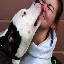

In [ ]:
test_image

In [ ]:
test_image = image.img_to_array(test_image)

In [ ]:
test_image

array([[[106.,  72.,  63.],
        [107.,  73.,  64.],
        [109.,  75.,  66.],
        ...,
        [ 23.,  22.,  17.],
        [ 83.,  48.,  42.],
        [ 98.,  64.,  55.]],

       [[106.,  72.,  63.],
        [107.,  73.,  64.],
        [109.,  75.,  66.],
        ...,
        [ 10.,   9.,   4.],
        [ 75.,  45.,  37.],
        [ 94.,  60.,  51.]],

       [[106.,  72.,  63.],
        [106.,  72.,  63.],
        [108.,  74.,  65.],
        ...,
        [  8.,   9.,   3.],
        [ 56.,  29.,  20.],
        [ 96.,  62.,  53.]],

       ...,

       [[ 31.,  26.,  22.],
        [ 34.,  29.,  26.],
        [ 21.,  16.,  13.],
        ...,
        [ 74.,  45.,  41.],
        [ 75.,  44.,  41.],
        [ 74.,  43.,  40.]],

       [[ 41.,  37.,  28.],
        [ 21.,  16.,  12.],
        [ 18.,  13.,  10.],
        ...,
        [ 36.,  18.,  14.],
        [ 64.,  41.,  35.],
        [ 74.,  45.,  41.]],

       [[ 31.,  27.,  18.],
        [ 23.,  18.,  14.],
        [ 20.,  

In [ ]:
test_image = np.expand_dims(test_image, axis=0)

In [ ]:
test_image

array([[[[106.,  72.,  63.],
         [107.,  73.,  64.],
         [109.,  75.,  66.],
         ...,
         [ 23.,  22.,  17.],
         [ 83.,  48.,  42.],
         [ 98.,  64.,  55.]],

        [[106.,  72.,  63.],
         [107.,  73.,  64.],
         [109.,  75.,  66.],
         ...,
         [ 10.,   9.,   4.],
         [ 75.,  45.,  37.],
         [ 94.,  60.,  51.]],

        [[106.,  72.,  63.],
         [106.,  72.,  63.],
         [108.,  74.,  65.],
         ...,
         [  8.,   9.,   3.],
         [ 56.,  29.,  20.],
         [ 96.,  62.,  53.]],

        ...,

        [[ 31.,  26.,  22.],
         [ 34.,  29.,  26.],
         [ 21.,  16.,  13.],
         ...,
         [ 74.,  45.,  41.],
         [ 75.,  44.,  41.],
         [ 74.,  43.,  40.]],

        [[ 41.,  37.,  28.],
         [ 21.,  16.,  12.],
         [ 18.,  13.,  10.],
         ...,
         [ 36.,  18.,  14.],
         [ 64.,  41.,  35.],
         [ 74.,  45.,  41.]],

        [[ 31.,  27.,  18.],
       

In [ ]:
result = cnn.predict(test_image)
class_labels = training_set.class_indices
print(f"Class indices: {class_labels}")

# Reverse the class_indices dictionary to map index to label
idx_to_label = {v: k for k, v in class_labels.items()}

# Determine prediction based on probability threshold
# Assuming result[0][0] is the probability for the class mapped to 1
# (e.g., if {'cats': 0, 'dogs': 1}, then result[0][0] is prob of dog)

if result[0][0] > 0.5:
  predicted_index = 1
else:
  predicted_index = 0

prediction = idx_to_label[predicted_index]

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Class indices: {'cats': 0, 'dogs': 1}
dogs
